<a href="https://colab.research.google.com/github/ompatel420/ML-Practicals/blob/main/ML_P4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt  # seaborn
import pandas as pd

In [2]:
dataset = pd.read_csv('/content/drive/MyDrive/ML/Dataset/car data_(2).csv')
dataset

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [3]:
print(dataset.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [4]:
current_year = 2021
if 'Year' in dataset.columns:
    dataset['Vehicle_Age'] = current_year - dataset['Year']
    dataset.drop('Year', axis=1, inplace=True)

In [5]:
print(dataset.head())

  Car_Name  Selling_Price  Present_Price  Kms_Driven Fuel_Type Seller_Type  \
0     ritz           3.35           5.59       27000    Petrol      Dealer   
1      sx4           4.75           9.54       43000    Diesel      Dealer   
2     ciaz           7.25           9.85        6900    Petrol      Dealer   
3  wagon r           2.85           4.15        5200    Petrol      Dealer   
4    swift           4.60           6.87       42450    Diesel      Dealer   

  Transmission  Owner  Vehicle_Age  
0       Manual      0            7  
1       Manual      0            8  
2       Manual      0            4  
3       Manual      0           10  
4       Manual      0            7  


/tmp/ipykernel_632/3847984748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=dataset, palette='Set2')
/tmp/ipykernel_632/3847984748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=dataset, palette='Set2')
/tmp/ipykernel_632/3847984748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=dataset, palette='Set2')
/tmp/ipykernel_632/3847984748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

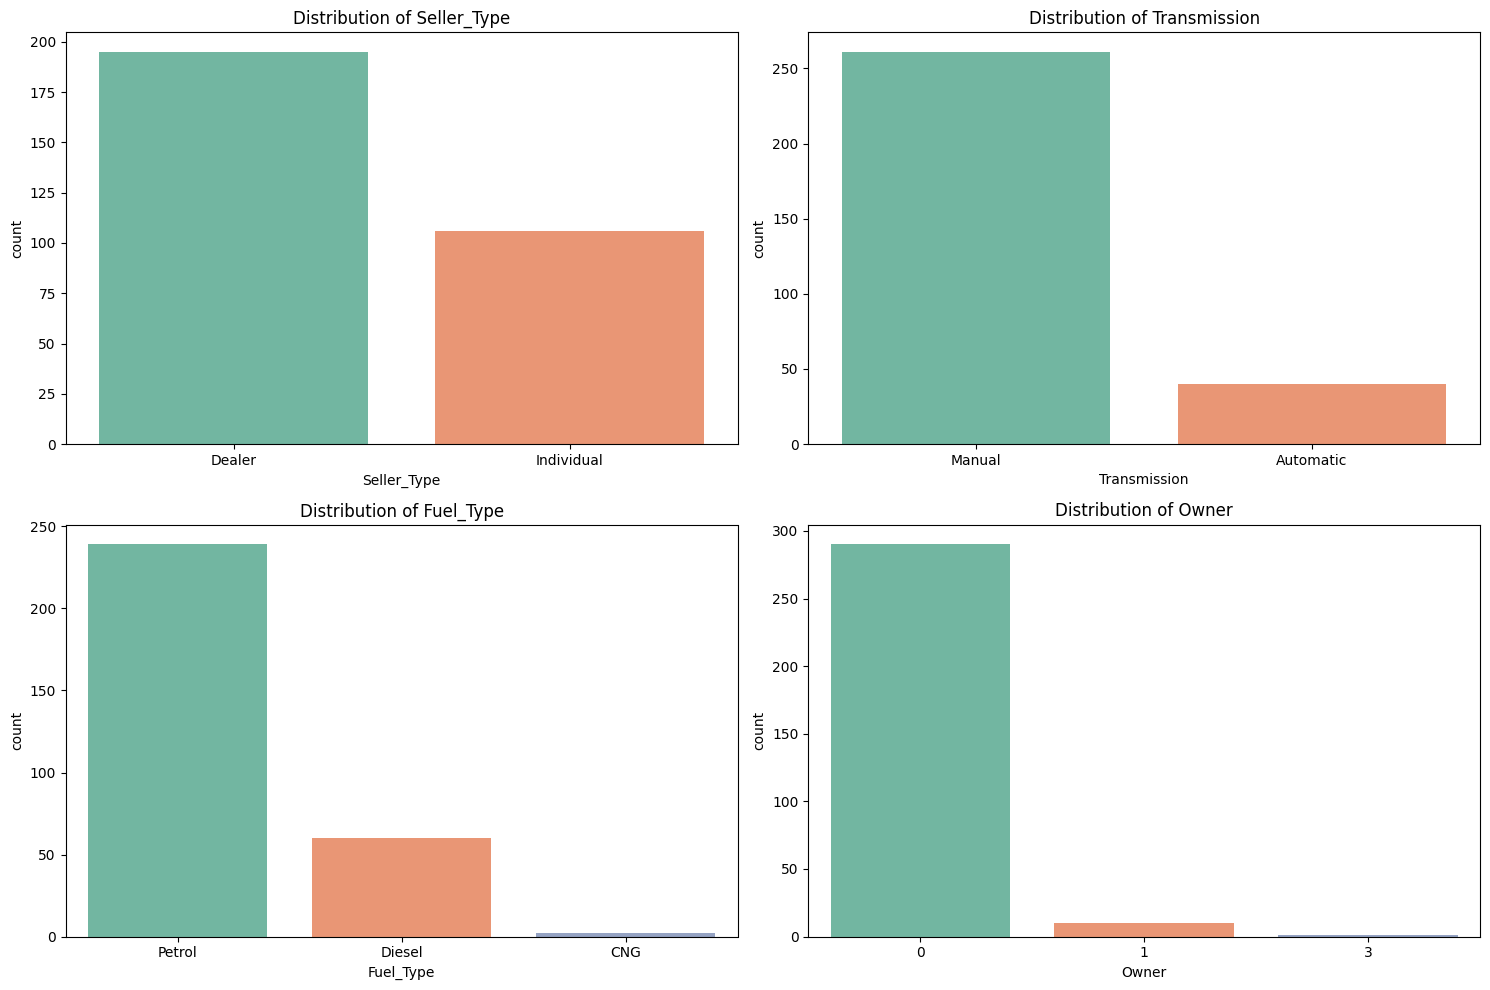

/tmp/ipykernel_632/3847984748.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Vehicle_Age', data=dataset, palette='viridis')


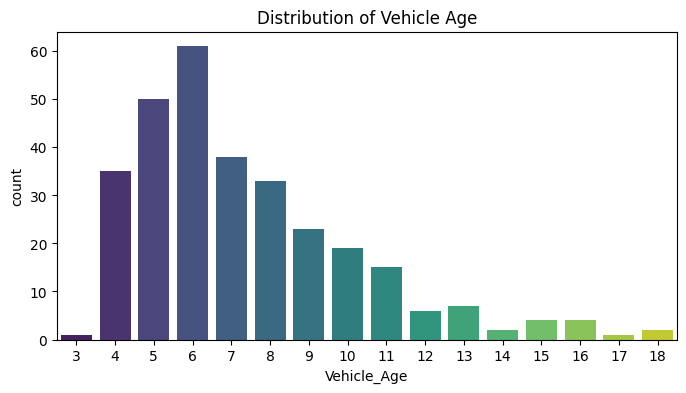

In [6]:
import seaborn as sns
categorical_cols = ['Seller_Type', 'Transmission', 'Fuel_Type', 'Owner']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=dataset, palette='Set2')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='Vehicle_Age', data=dataset, palette='viridis')
plt.title('Distribution of Vehicle Age')
plt.show()

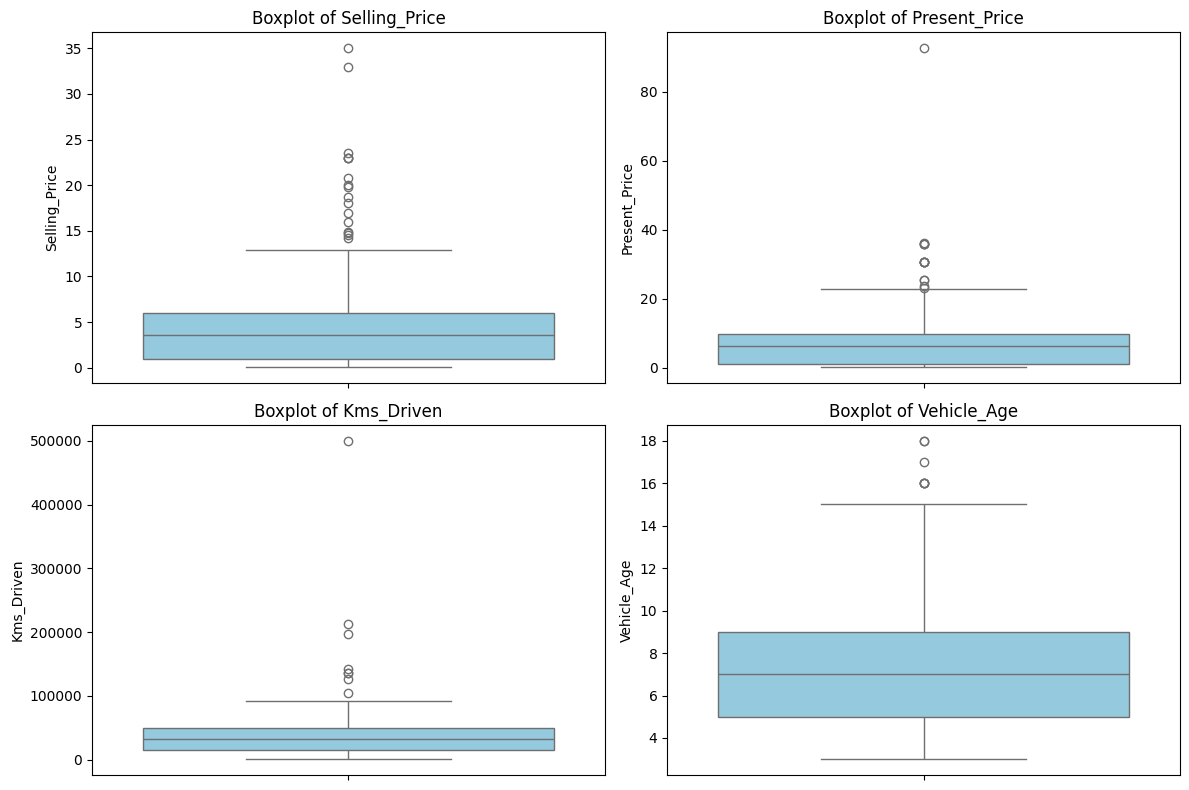

In [7]:
num_outlier_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Vehicle_Age']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_outlier_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [8]:
numerical_df = dataset.select_dtypes(include=['int64', 'float64'])
numerical_df

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age
0,3.35,5.59,27000,0,7
1,4.75,9.54,43000,0,8
2,7.25,9.85,6900,0,4
3,2.85,4.15,5200,0,10
4,4.60,6.87,42450,0,7
...,...,...,...,...,...
296,9.50,11.60,33988,0,5
297,4.00,5.90,60000,0,6
298,3.35,11.00,87934,0,12
299,11.50,12.50,9000,0,4


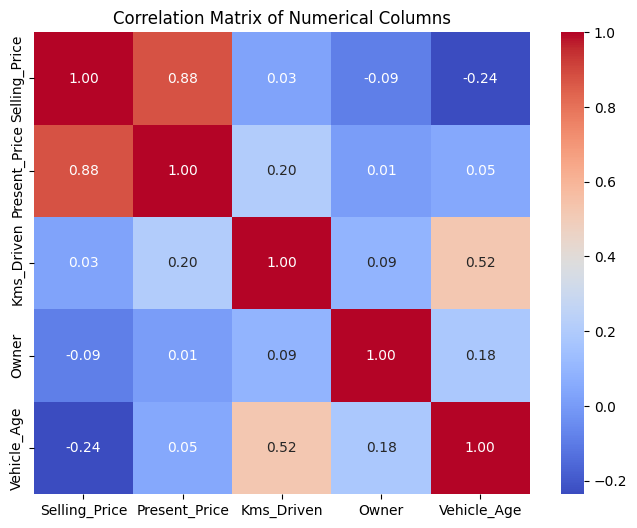

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

In [10]:
dataset.drop('Car_Name', axis=1, inplace=True)

In [11]:
import pandas as pd
dataset = pd.get_dummies(dataset, drop_first=True)
dataset

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,7,False,True,False,True
1,4.75,9.54,43000,0,8,True,False,False,True
2,7.25,9.85,6900,0,4,False,True,False,True
3,2.85,4.15,5200,0,10,False,True,False,True
4,4.60,6.87,42450,0,7,True,False,False,True
...,...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,0,5,True,False,False,True
297,4.00,5.90,60000,0,6,False,True,False,True
298,3.35,11.00,87934,0,12,False,True,False,True
299,11.50,12.50,9000,0,4,True,False,False,True


In [12]:
X = dataset.drop('Selling_Price', axis=1)
y = dataset['Selling_Price']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_train_score = lr_model.score(X_train_scaled, y_train)
lr_test_score = lr_model.score(X_test_scaled, y_test)

print(f"\n[Linear Regression] Train R2 Score: {lr_train_score:.4f}")
print(f"[Linear Regression] Test R2 Score: {lr_test_score:.4f}")


[Linear Regression] Train R2 Score: 0.8887
[Linear Regression] Test R2 Score: 0.8490


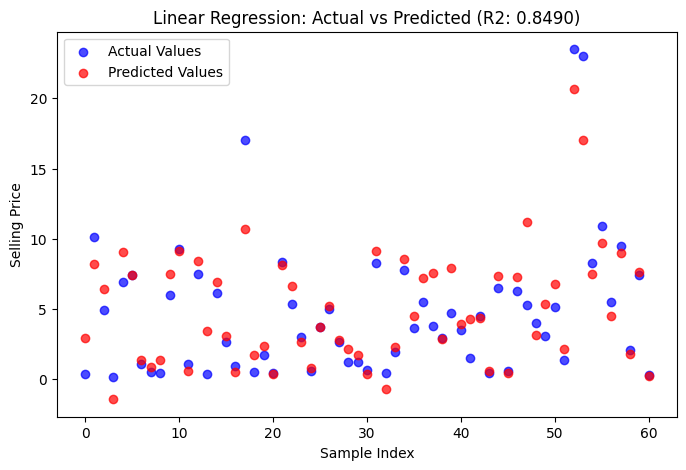

In [16]:
from sklearn.metrics import r2_score

lr_preds = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test, lr_preds)

plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Values', alpha=0.7)
plt.scatter(range(len(lr_preds)), lr_preds, color='red', label='Predicted Values', alpha=0.7)
plt.title(f'Linear Regression: Actual vs Predicted (R2: {lr_r2:.4f})')
plt.xlabel('Sample Index')
plt.ylabel('Selling Price')
plt.legend()
plt.show()

In [17]:
from sklearn.svm import SVR

svr_base = SVR()
svr_base.fit(X_train_scaled, y_train)

print(f"\n[Baseline SVR] Train R2 Score: {svr_base.score(X_train_scaled, y_train):.4f}")
print(f"[Baseline SVR] Test R2 Score: {svr_base.score(X_test_scaled, y_test):.4f}")


[Baseline SVR] Train R2 Score: 0.6565
[Baseline SVR] Test R2 Score: 0.7777
